# 4. Artificial Neural Network (ANN)

This notebook trains a **feedforward ANN** with 2 hidden layers for binary classification. Key design choices:

- **ReLU** activations on hidden layers (avoids vanishing gradients)
- **Sigmoid** on the output layer (binary probability)
- **Dropout + BatchNormalization** for regularisation
- **EarlyStopping** to prevent overfitting

> **Colab Setup** — La cella seguente configura automaticamente l'ambiente Google Colab. Se stai eseguendo il notebook in locale, verrà saltata automaticamente.

In [ ]:
# ── Colab Setup ──────────────────────────────────────────────
import sys, os

if 'google.colab' in sys.modules:
    if not os.path.exists('ecommerce-intention'):
        !git clone -q https://github.com/davidemeta/Predicting-Online-Shoppers-Purchasing-Intention.git ecommerce-intention
    os.chdir('ecommerce-intention/notebooks')
    !pip install -q -r ../requirements.txt

    # Riesegui preprocessing se i dati non esistono ancora
    if not os.path.exists('../data/preprocessed_data.npz'):
        sys.path.insert(0, str(os.path.abspath('..')))
        from src.preprocessing import load_data, encode_features, split_and_scale, apply_smote
        import numpy as np
        from pathlib import Path

        df = load_data(Path('../data/online_shoppers_intention.csv'))
        df = encode_features(df)
        X = df.drop('Revenue', axis=1)
        y = df['Revenue']
        X_train, X_test, y_train, y_test, scaler, feature_names = split_and_scale(X, y)
        X_train_res, y_train_res = apply_smote(X_train, y_train)

        np.savez('../data/preprocessed_data.npz',
                 X_train=X_train_res, X_test=X_test,
                 y_train=y_train_res, y_test=y_test)
        np.save('../data/feature_names.npy', np.array(feature_names))
        print('Preprocessing completato')

    print('Colab setup completato')

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Set seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

sns.set_style('whitegrid')

In [2]:
# Load preprocessed data
data = np.load('../data/preprocessed_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = np.load('../data/feature_names.npy', allow_pickle=True)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (16676, 17)
Test set:     (2466, 17)


In [3]:
from src.models import build_ann, train_ann
from src.evaluation import compute_metrics, plot_confusion_matrix, plot_roc_curve

## 4.1 Model Architecture

| Layer | Type | Units / Config | Activation | Purpose |
|-------|------|---------------|------------|----------|
| 1 | Dense | 128 | ReLU | First hidden layer — learns feature interactions |
| 2 | BatchNorm | — | — | Normalises layer outputs for stable training |
| 3 | Dropout | 0.3 | — | Regularisation — prevents overfitting |
| 4 | Dense | 64 | ReLU | Second hidden layer — refines representations |
| 5 | BatchNorm | — | — | Normalises layer outputs |
| 6 | Dropout | 0.3 | — | Additional regularisation |
| 7 | Dense | 1 | Sigmoid | Output — purchase probability [0, 1] |

### Why ReLU Instead of Sigmoid on Hidden Layers?

**Sigmoid** squashes outputs to [0, 1], causing gradients to vanish in deep networks — gradients are multiplied across layers, and since Sigmoid's max gradient is 0.25, they shrink exponentially.

**ReLU** (`max(0, x)`) has a gradient of 1 for positive inputs, enabling efficient gradient flow even through multiple layers.

In [4]:
ann_model = build_ann(X_train.shape[1])
ann_model.summary()

/Users/davidemeta/Documents/Università/Terzo anno/Secondo semestre/Intelligenza Artificiale e Apprendimento Automatico/Project/ecommerce-intention/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 384 (1.50 KB)

## 4.2 Model Training

A 15% validation split from the training set is used for early stopping monitoring.

In [5]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

print(f'Training subset: {X_tr.shape}')
print(f'Validation set:  {X_val.shape}')

Training subset: (14174, 17)
Validation set:  (2502, 17)


In [6]:
ann_model, history = train_ann(
    ann_model, X_tr, y_tr, X_val, y_val,
    epochs=100, batch_size=32
)

Epoch 1/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 1s 609us/step - accuracy: 0.7737 - loss: 0.4879 - val_accuracy: 0.8429 - val_loss: 0.3752
Epoch 2/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.8288 - loss: 0.3886 - val_accuracy: 0.8493 - val_loss: 0.3514
Epoch 3/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - accuracy: 0.8468 - loss: 0.3604 - val_accuracy: 0.8593 - val_loss: 0.3350
Epoch 4/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.8561 - loss: 0.3396 - val_accuracy: 0.8661 - val_loss: 0.3229
Epoch 5/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.8614 - loss: 0.3330 - val_accuracy: 0.8609 - val_loss: 0.3219
Epoch 6/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.8625 - loss: 0.3258 - val_accuracy: 0.8641 - val_loss: 0.3133
Epoch 7/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.8701 - loss: 0.3175 - val_accuracy: 0.8701 - val_loss: 0.3061
Epoch 8/100
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step - accuracy: 0.8705 - loss: 0

## 4.3 Training History

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('ANN Training History', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../report/Resources/ann_training_history.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(f'Training stopped at epoch {len(history.history["loss"])}')

## 4.4 Evaluation

In [8]:
ann_results = compute_metrics(ann_model, X_test, y_test, 'ANN')

print(f"Accuracy:  {ann_results['accuracy']:.4f}")
print(f"Precision: {ann_results['precision']:.4f}")
print(f"Recall:    {ann_results['recall']:.4f}")
print(f"F1-Score:  {ann_results['f1']:.4f}")
print(f"ROC-AUC:   {ann_results['roc_auc']:.4f}")
print(f"\nClassification Report:\n{ann_results['report']}")

Accuracy:  0.8528
Precision: 0.5174
Recall:    0.7408
F1-Score:  0.6093
ROC-AUC:   0.8946

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      2084
           1       0.52      0.74      0.61       382

    accuracy                           0.85      2466
   macro avg       0.73      0.81      0.76      2466
weighted avg       0.88      0.85      0.86      2466



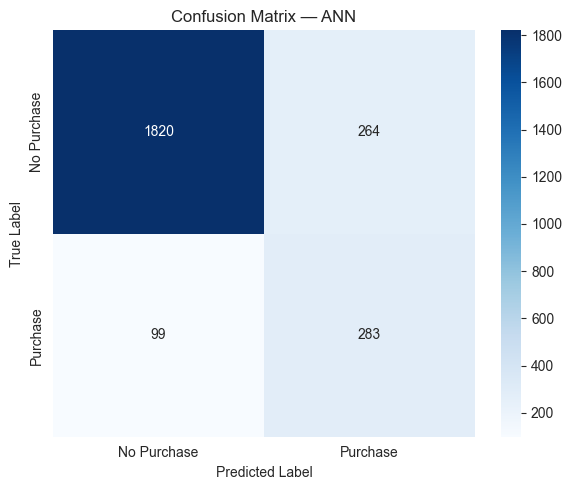

In [9]:
plot_confusion_matrix(y_test, ann_results['y_pred'], 'ANN')

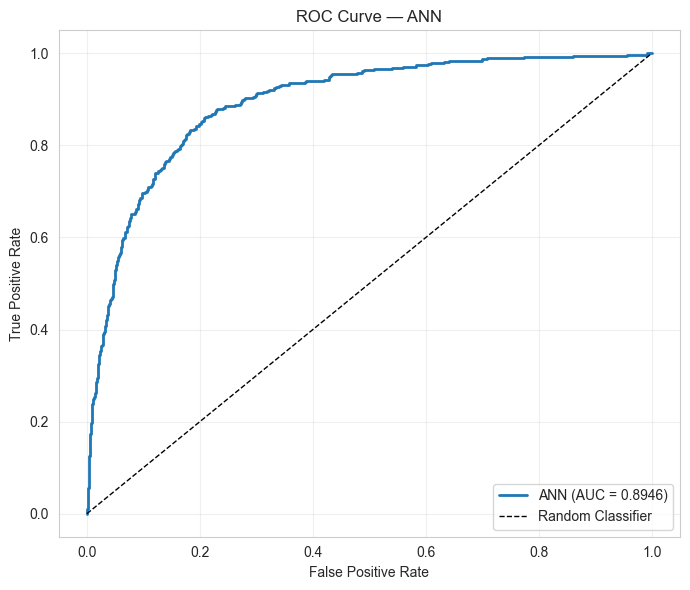

In [10]:
plot_roc_curve(y_test, ann_results['y_proba'], 'ANN')

## 4.5 Summary

The ANN model provides a **non-linear** approach to purchase prediction:

- ReLU activations enable effective learning across both hidden layers.
- Dropout (0.3) and BatchNormalization help prevent overfitting.
- EarlyStopping ensures the model generalises well to unseen data.
- The training history shows convergence without significant overfitting.

In [11]:
# Save model and results
save_dir = Path('../data')
ann_model.save(save_dir / 'ann_model.keras')

ann_results_save = {
    'model_name': ann_results['model_name'],
    'y_pred': ann_results['y_pred'],
    'y_proba': ann_results['y_proba'],
    'accuracy': ann_results['accuracy'],
    'precision': ann_results['precision'],
    'recall': ann_results['recall'],
    'f1': ann_results['f1'],
    'roc_auc': ann_results['roc_auc'],
}
with open(save_dir / 'ann_results.pkl', 'wb') as f:
    pickle.dump(ann_results_save, f)

print('Model and results saved.')

Model and results saved.
